In [37]:
import pandas as pd
import numpy as np
import requests
import gdown
from io import StringIO

import Investment_tool as it

import matplotlib.pyplot as plt

import yfinance as yf

# Data Scraping

In [38]:
url = 'https://www.iposcoop.com/ipos-recently-filed/'

headers = {'User-Agent': 'Mozilla/5.0 (learning project)'}

In [39]:
response = requests.get(url= url, headers= headers)
response.raise_for_status()

In [40]:
data = pd.read_html(StringIO(response.text), attrs= {'class':'ipolist'})
data = data[0]

In [41]:
# Filter IPO withdrawns

withdrawn = data[data['Expected To Trade']=='Withdrawn']

In [42]:
# Tranform date

withdrawn['File Date'] = pd.to_datetime(withdrawn['File Date'], format= '%Y-%m-%d')

C:\Users\USER\AppData\Local\Temp\ipykernel_33280\1566459102.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  withdrawn['File Date'] = pd.to_datetime(withdrawn['File Date'], format= '%Y-%m-%d')


In [43]:
# Cleaning floats

withdrawn.iloc[:,5:8] = withdrawn.iloc[:,5:8].map(lambda x: float(x.replace('$','')),na_action= 'ignore')

In [44]:
# Categorize Companies

conditions =[
    withdrawn['Company'].str.contains('Technologies', case= False, regex= True),
    withdrawn['Company'].str.contains('Corp|Acquisition Corp', case= False, regex= True),
    withdrawn['Company'].str.contains('Inc',case= False, regex= True),
    withdrawn['Company'].str.contains('Group', case= False),
    withdrawn['Company'].str.contains('Ltd|Limited', case= False, regex= True),
    withdrawn['Company'].str.contains('Holding', case= False, regex= True),
]

category = ['Technology', 'Acquisition Corp', 'Inc', 'Group', 'Limited', 'Holdings']

withdrawn['Company type'] = np.select(conditions, category, default= 'Other')

C:\Users\USER\AppData\Local\Temp\ipykernel_33280\3650149973.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  withdrawn['Company type'] = np.select(conditions, category, default= 'Other')


In [45]:
# Create value company 

withdrawn['Avg_price'] = (withdrawn['Price Low'] + withdrawn['Price High'])/2

C:\Users\USER\AppData\Local\Temp\ipykernel_33280\541924206.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  withdrawn['Avg_price'] = (withdrawn['Price Low'] + withdrawn['Price High'])/2


In [46]:
withdrawn['Shares_offered_value'] = withdrawn['Shares (millions)']*withdrawn['Avg_price']

C:\Users\USER\AppData\Local\Temp\ipykernel_33280\30106377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  withdrawn['Shares_offered_value'] = withdrawn['Shares (millions)']*withdrawn['Avg_price']


In [47]:
# Filter dates til 11th september 2026

withdrawn_1 = withdrawn[withdrawn['File Date'] < '2026-09-11']

In [48]:
# Answer
withdrawn_1[['Company type', 'Shares_offered_value']].groupby(by='Company type').sum()

,Shares_offered_value
Company type,
Acquisition Corp,499.985
Group,32.5
Holdings,311.6575
Inc,351.0
Limited,62.25
Other,115.445
Technology,84.9


Question 2: What is the median Sharpe ratio (as of 11 September 2026) for companies that went public before 1 September 2025? (3 points)

In [49]:
url = 'https://www.iposcoop.com/2025-pricings/'

headers = {'User-Agent': 'Mozilla/5.0 (learning project)'}

In [50]:
response = requests.get(url= url, headers= headers)
response.raise_for_status()

In [51]:
data = pd.read_html(StringIO(response.text), attrs= {'class':'ipolist'})
data = data[0]

In [52]:
data['Offer Date'] = pd.to_datetime(data['Offer Date'], format= '%m/%d/%Y')

In [53]:
cols = data.columns[5:8]   # ['Offer Price', '1st Day Close', 'Current Price']

data[cols] = data[cols].map(lambda x: float(str(x).replace('$', '')))

In [54]:
data['Return'] = data['Return'].map(lambda x: (float(x.replace('%',''))/100)).astype('float64')

In [55]:
tickers = data[(data['Offer Date'] < '2025-09-01') & (data['Return']!=0)]

In [56]:
tickers = tickers[~tickers['Symbol'].isin(['SKBL', 'CAEP', 'WGRX', 'CEPT', 'MJID', 'AHL', 'AGH', 'MTSR', 'TBH', 'EMPG', 'SDM', 'EPWK', 'MCTR', 'PTNM'])]

In [57]:
# Parameters for downloading data

symbol = list(tickers['Symbol'])

end_date = '2026-09-12'
start_date = '2025-01-01'

In [58]:
stock_r = yf.download(tickers= symbol, start= start_date, end= end_date)['Close'].pct_change()

[*********************100%***********************]  132 of 132 completed
C:\Users\USER\AppData\Local\Temp\ipykernel_33280\3480336848.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stock_r = yf.download(tickers= symbol, start= start_date, end= end_date)['Close'].pct_change()


In [59]:
stock_r_shift = stock_r.shift(1)

In [60]:
growth = stock_r / stock_r_shift

In [61]:
volatility = stock_r.rolling(30).agg(it.annual_vol, 252)

In [62]:
sharpe_ratio = (growth - 0.05)/volatility

In [63]:
sharpe_ratio = sharpe_ratio.replace([np.inf, -np.inf], np.nan)

In [64]:
descriptive = sharpe_ratio.describe()

In [65]:
# Answer
descriptive.loc['50%'].median()

np.float64(-0.06459532935341834)

Question 3: What is the optimal number of months (1 to 12) to hold a newly IPO'd stock in order to maximize the median growth value?

In [66]:
stock_r

Ticker,AAPG,AARD,ADVB,AII,AIRO,ALM,AMBQ,ANPA,ANTA,APUS,...,VOYG,WETO,WFF,WTF,WXM,WYFI,XHLD,YMAT,YMT,ZYBT
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,NaN,NaN,NaN,NaN,NaN,0.044928,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-06,NaN,NaN,NaN,NaN,NaN,-0.012483,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-07,NaN,NaN,NaN,NaN,NaN,-0.004213,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-08,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.074074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-04,0.014689,-0.061082,-0.006915,-0.006116,0.045198,-0.015135,0.018075,0.044462,0.056180,-0.035857,...,0.038556,-0.208075,-0.009709,-0.021505,-0.003315,0.040469,0.001083,-0.073973,0.121693,-0.012270
2026-09-08,-0.009935,-0.009294,-0.038029,0.007692,-0.009459,0.088219,0.037772,-0.168766,-0.083777,-0.049587,...,0.043312,-0.003922,-0.058824,0.000000,-0.044346,0.052712,0.015152,-0.215976,0.051887,-0.018634
2026-09-09,-0.007454,-0.076923,-0.053452,-0.010687,-0.061392,-0.041318,0.069608,-0.057576,0.036865,-0.004348,...,-0.046879,-0.051181,-0.020833,-0.047619,-0.062645,-0.061254,0.120469,0.713207,-0.049327,-0.006329


In [67]:
dict= {}

for time in list(range(21,253,21)):
    growth_r = []

    for stock in stock_r.columns:
        valid_idx = stock_r[stock].first_valid_index()
        value = (stock_r.loc[valid_idx:valid_idx+pd.Timedelta(days= time),stock]+1).prod()

        growth_r.append(value)

    dict[f'Growth_{time}days']=growth_r

In [68]:
growth_by_month = pd.DataFrame(dict,index= stock_r.columns)

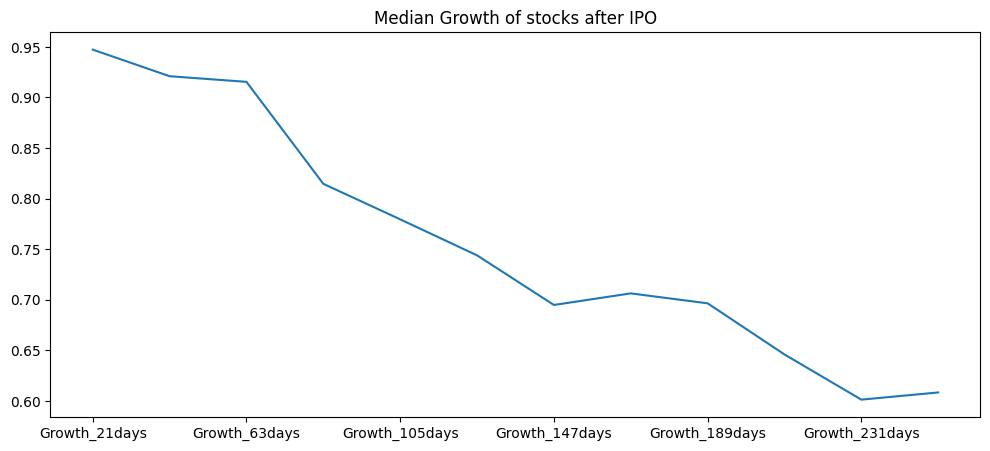

In [69]:
# Answer
descriptive = growth_by_month.describe()
descriptive.loc['50%',:].plot(figsize= (12,5))
plt.title('Median Growth of stocks after IPO')
plt.show()

Question 4: What is the total profit (in $ thousands) you would have earned by investing $1000 every time a stock was oversold (RSI < 30)?

In [70]:
file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet= False)
df = pd.read_parquet("data.parquet", engine="pyarrow")

Downloading...
From (original): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-
From (redirected): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-&confirm=t&uuid=55e1393d-13b2-4b0f-a040-20f9c7f9d7ea
To: c:\Users\USER\Documents\Programación\Stock market zoomcamp\data.parquet
100%|██████████| 130M/130M [00:16<00:00, 7.95MB/s] 


In [71]:
df_rsi = df[df['rsi']<30]

In [72]:
df_rsi = df_rsi[(df_rsi['Date']>'2000-01-01')&(df_rsi['Date']<'2025-06-01')]

In [73]:
# Net income by investing 1000$ dollars

df_rsi['net_incom_30d'] = 1000*(df_rsi['growth_future_30d']-1)

In [74]:
# Answer
df_rsi['net_incom_30d'].sum(axis=0)

np.float64(65805.58960747934)